# ML Vegetation Classification via Server-Side UDF

This notebook classifies burned forest vegetation using a Random Forest trained and applied **server-side** via `apply_dimension` on a raster DataCube.
```
Sync download:    load_collection → aggregate_spatial(label points) → download JSON
                                            ↓
                              features passed into UDF context
                                            ↓
Large batch job:  load_collection → apply_dimension(bands, UDF) → GeoTIFF
```



## Overview

1. Import Required Libraries
2. Connect to OpenEO Backend
3. Prepare Training Data
   - 3.1 Load NFI Labels
   - 3.2 Download Spectral Features at Label Locations (small batch job)
4. Load Fire Mask for Visualization
5. Define ML UDF
6. Submit Prediction Batch Job
7. Visualize Results

## 1. Import Required Libraries

In [1]:
import glob
import json
import textwrap

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
import rasterio
import geopandas

import openeo
from openeo import UDF
from openeo_udp import ParameterManager

## 2. Connect to OpenEO Backend

In [2]:
param_manager = ParameterManager('dNBR_Portugal.params.py')

connection, current_params = param_manager.quick_connect(
    param_set="reriz_gafanhao_north_portugal_2024",
    endpoint="copernicus_dataspace",
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: reriz_gafanhao_north_portugal_2024
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Reriz e Gafanhao, North Portugal
🔄 Parameters mapped for endpoint copernicus_dataspace:


In [3]:
def load_and_sample(params, time, bands, res=100):
    """Load a Sentinel-2 collection reduced to the last image and resampled."""
    s2cube = connection.load_collection(
        params["collection"].default,
        temporal_extent=time,
        spatial_extent=params["bounding_box"].default,
        bands=bands,
        properties={"eo:cloud_cover": lambda x: x <= params["cloud_cover"].default},
    )
    s2cube = s2cube.reduce_dimension(dimension="t", reducer="last")
    s2cube = s2cube.resample_spatial(resolution=[res, res], method="near")
    return s2cube


def download_cube(cube, out_folder, out_format, batch=True):
    """
    Input: Cube to download, output folder, output format (e.g. "JSON", "GTiff"),
           batch (False skips the batch-job queue for small/fast results —
           out_folder is then used directly as the output file path)
    Output: None, downloads the cube's results into out_folder
    """
    if batch:
        job = cube.create_job(out_format=out_format)
        job.start_and_wait()
        job.get_results().download_files(out_folder)
    else:
        cube.download(out_folder, format=out_format)

## 3. Prepare Training Data

### 3.1 Load NFI Labels

In [4]:
nfi_labels = geopandas.read_file("nfi_labels.geojson")
geojson_labels = json.loads(nfi_labels[["label", "geometry"]].to_json())

y_train_str = nfi_labels["label"].values.tolist()
label_names = sorted(set(y_train_str))  # sorted list — index = integer class ID

### 3.2 Download Features at Label Locations

In [5]:
res = 20
s2_train = load_and_sample(
    current_params,
    current_params["time_post"].default,
    current_params["bands_ml"].default,
    res,
)

features_cube = s2_train.aggregate_spatial(geojson_labels, reducer="mean")

features_out_file = "training_features.json"
download_cube(features_cube, features_out_file, "JSON", batch=False)

with open(features_out_file) as f:
    raw_train = json.load(f)

X_train = np.array(raw_train, dtype=float) 

## 4. Load Fire Mask for Visualization

Loads the pre-cleaned fire mask directly from `dNBR_Portugal.ipynb`'s saved `clean_mask_*.tif` — connected-component filtering already happened there, so it isn't repeated here.

In [6]:
clean_mask_file = "clean_mask_reriz_e_gafanhao_north_portugal.tif"
with rasterio.open(clean_mask_file) as src:
    clean_mask = src.read(1)

## 5. Define ML UDF

The UDF uses the `apply_datacube` signature and is submitted to the backend as a code string. The backend calls it once per spatial chunk of the S2 raster.

Inside the UDF:
1. Reconstruct `X_train`/`y_train` from `context`
2. Train a `RandomForestClassifier` on the training set
3. Reshape the chunk and predict a class ID per pixel
4. Return predicted class labels

Training data is small (~500 pts × n bands) and the model is deterministic, so re-training per chunk is fast and always yields the same result.

In [ ]:
udf_code = textwrap.dedent("""
    import numpy as np
    import xarray as xr
    from sklearn.ensemble import RandomForestClassifier

    def apply_datacube(cube: xr.DataArray, context: dict) -> xr.DataArray:
        X_train   = np.array(context["X_train"])
        y_train   = np.array(context["y_train"])
        label_names = context["label_names"]         # sorted list; index == class ID
        class_to_int = {cls: float(i) for i, cls in enumerate(label_names)}

        # Train on the full training set (fast: ~500 pts, 2 bands)
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_train, y_train)

        # Predict on the raster chunk: (n_bands, height, width)
        arr = cube.values
        n_bands, height, width = arr.shape
        X_pred = arr.reshape(n_bands, -1).T          # (pixels, n_bands)
        valid  = ~np.isnan(X_pred).any(axis=1)

        preds_str  = np.full(height * width, "NoData", dtype=object)    
        preds_str[valid] = clf.predict(X_pred[valid])
        preds_float = np.array([class_to_int.get(p, -1.0) for p in preds_str])

        return xr.DataArray(
            preds_float.reshape(1, height, width),
            dims=cube.dims,
        )
""")

## 6. Submit Prediction Batch Job

`context` carries the training features + labels. The prediction raster is processed entirely server-side — only the single-band classification GeoTIFF is downloaded.

In [ ]:
context = {
    "X_train":     X_train.tolist(),   # (n_points, n_bands) as plain Python lists
    "y_train":     y_train_str,
    "label_names": label_names,
}

udf = UDF(code=udf_code, runtime="Python", context=context)

# Prediction cube stays server-side — UDF is applied along the bands dimension
s2_pred = load_and_sample(
    current_params,
    current_params["time_post"].default,
    current_params["bands_ml"].default,
    res,
)
result = s2_pred.apply_dimension(process=udf, dimension="bands")

pred_out_folder = "udf_prediction"
download_cube(result, pred_out_folder, "GTiff")

0:00:00 Job 'j-2607061203244ef1b483d4b86f4533a5': send 'start'
0:00:03 Job 'j-2607061203244ef1b483d4b86f4533a5': created (progress 0%)
0:00:08 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:00:14 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:00:23 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:00:35 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:00:48 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:01:03 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:01:23 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:01:48 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:02:18 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:02:56 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:03:43 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:04:41 Job 'j-2607061203244ef1b483d4b86f4533a5': queued (progress 0%)
0:05:41 Job '

## 7. Visualize Results

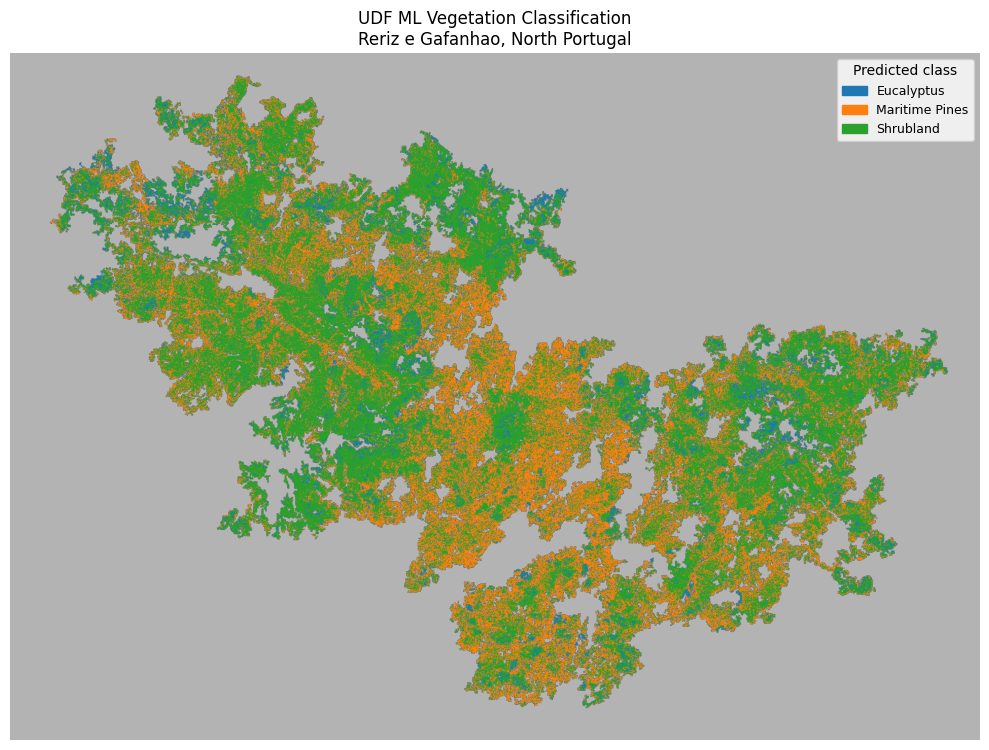

In [ ]:
pred_tiff = glob.glob("udf_prediction/*.tif")[0]
with rasterio.open(pred_tiff) as src:
    pred_raster = src.read(1).astype(float)

pred_raster[pred_raster < 0] = np.nan  # -1 → NoData
pred_fire = np.where(clean_mask == 1, pred_raster, np.nan)

n_classes = len(label_names)
colors = [plt.get_cmap("tab10")(i) for i in range(n_classes)]
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=np.arange(-0.5, n_classes, 1), ncolors=n_classes)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(clean_mask, cmap="gray", interpolation="none", alpha=0.3)
ax.imshow(pred_fire, cmap=cmap, norm=norm)
legend_patches = [mpatches.Patch(color=colors[i], label=name) for i, name in enumerate(label_names)]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, title="Predicted class")
ax.set_title(f"UDF ML Vegetation Classification\n{current_params['location_name']}")
ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
fire_preds = pred_raster[clean_mask == 1]
fire_preds = fire_preds[~np.isnan(fire_preds)].astype(int)

print("Prediction counts in fire area:")
for i, name in enumerate(label_names):
    count = (fire_preds == i).sum()
    pct = 100 * count / len(fire_preds)
    print(f"  {name:<18} {count:>7,}  ({pct:.1f}%)")
print(f"  {'Total':<18} {len(fire_preds):>7,}")

Prediction counts in fire area:
  Eucalyptus          94,047  (11.7%)
  Maritime Pines     271,960  (33.8%)
  Shrubland          437,702  (54.5%)
  Total              803,709
